# **A3 Predicing Car Prices** *ML AUG-2026*

## Submitted By: *Anish Lal Manandhar (st125973)*

**GIT REPO:**   https://github.com/anishDevMage/ML-August-2026-A3-st125973

**APP HOSTED ON:**  http://192.41.170.105:8050/

### **Data Load**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

*Data Import*

In [2]:
df = pd.read_csv("Cars.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [3]:
df.shape

(8128, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [5]:
df['selling_price'].describe(include="number")

count    8.128000e+03
mean     6.382718e+05
std      8.062534e+05
min      2.999900e+04
25%      2.549990e+05
50%      4.500000e+05
75%      6.750000e+05
max      1.000000e+07
Name: selling_price, dtype: float64

### **Data Cleaning**
##### Few Initial Sections of Data Cleaning are performed similar to the previous assignments also since the same dataset is being used

##### *Duplicate check and drop*

In [6]:
# Check and delete for duplicates
print(df.duplicated().sum())
df = df.drop_duplicates()
df.shape

1202


(6926, 13)

In [7]:
# REMOVING ROW VALUES
df = df[~df['fuel'].isin(['CNG', 'LPG'])]
df = df[df['owner'] != 'Test Drive Car']

In [8]:
df[['mileage', 'engine', 'max_power']].dtypes

mileage      object
engine       object
max_power    object
dtype: object

Type Casting

In [9]:
df['mileage'] = df['mileage'].str.split().str[0].astype(float)
df['engine'] = df['engine'].str.split().str[0].astype(float)
df['max_power'] = df['max_power'].str.split().str[0].astype(float)

Drop Torque Column

In [10]:
# DROPPING FEATURES
df.drop('torque', axis=1, inplace=True)

*Fill Data*

In [11]:
df['brand'] = df['name'].str.split().str[0]
df['brand'] = df['brand'].fillna('Unknown')
df.drop(columns=['name'], inplace=True)

In [12]:
print("\nUnique brands in the dataset:")
print(df['brand'].unique())


Unique brands in the dataset:
['Maruti' 'Skoda' 'Honda' 'Hyundai' 'Toyota' 'Ford' 'Renault' 'Mahindra'
 'Tata' 'Chevrolet' 'Fiat' 'Datsun' 'Jeep' 'Mercedes-Benz' 'Mitsubishi'
 'Audi' 'Volkswagen' 'BMW' 'Nissan' 'Lexus' 'Jaguar' 'Land' 'MG' 'Volvo'
 'Daewoo' 'Kia' 'Force' 'Ambassador' 'Ashok' 'Isuzu' 'Opel' 'Peugeot']


##### *Null check and drop*

In [13]:
df.isnull().sum()

year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          201
engine           201
max_power        198
seats            201
brand              0
dtype: int64

In [14]:
# SMALL PERCENTAGE DELETED
df = df.dropna(subset=['mileage', 'engine', 'max_power', 'seats'])
df.isnull().sum()

year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
brand            0
dtype: int64

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6626 entries, 0 to 8125
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           6626 non-null   int64  
 1   selling_price  6626 non-null   int64  
 2   km_driven      6626 non-null   int64  
 3   fuel           6626 non-null   object 
 4   seller_type    6626 non-null   object 
 5   transmission   6626 non-null   object 
 6   owner          6626 non-null   object 
 7   mileage        6626 non-null   float64
 8   engine         6626 non-null   float64
 9   max_power      6626 non-null   float64
 10  seats          6626 non-null   float64
 11  brand          6626 non-null   object 
dtypes: float64(4), int64(3), object(5)
memory usage: 673.0+ KB


## Explanatory Data Analysis (EDA)

0 selling_price
1 km_driven
2 mileage
3 engine
4 max_power
5 seats


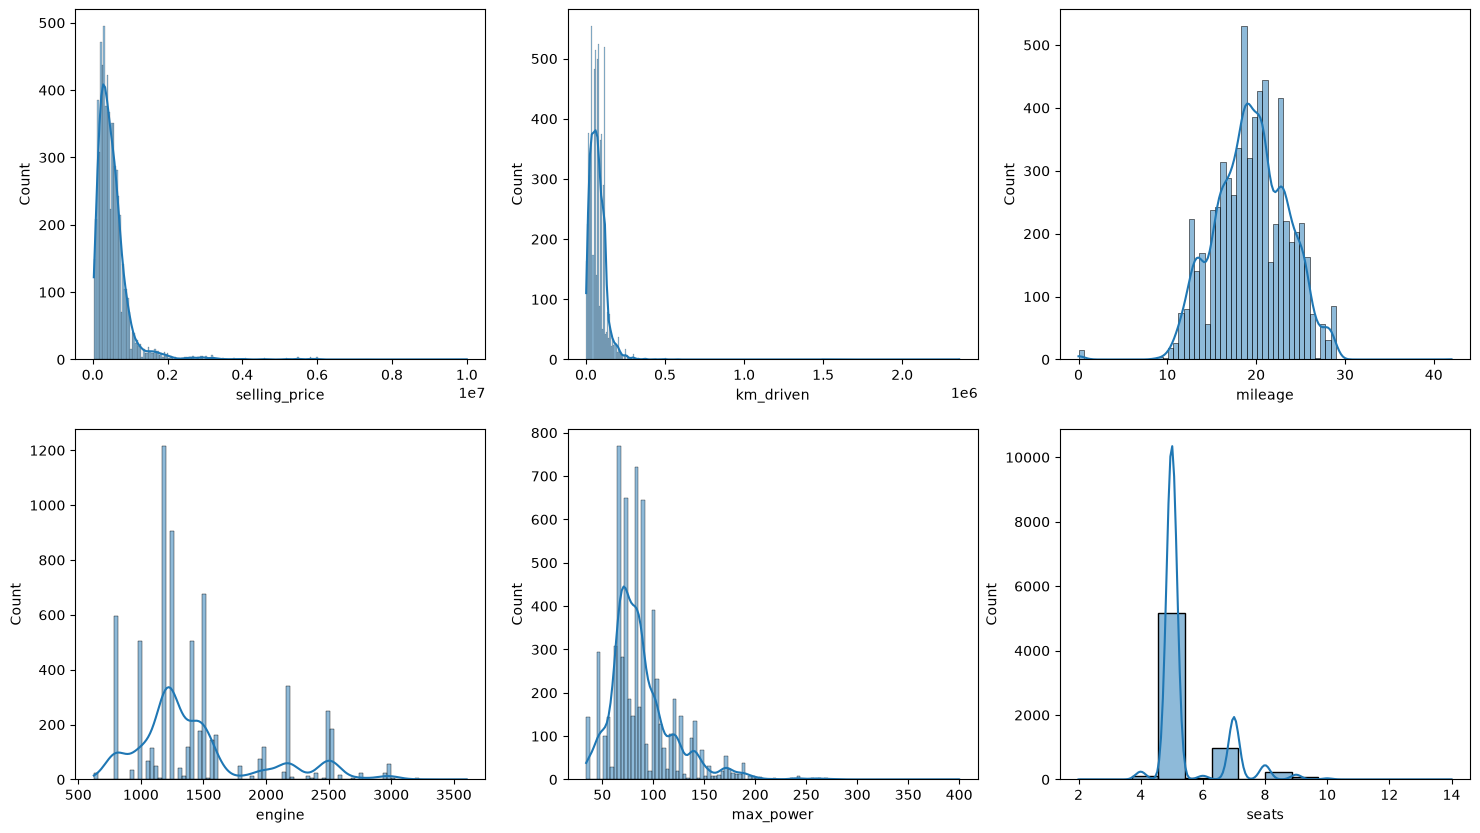

In [16]:

# ARE THESE EDA graphs ENOUGH ?


fig , axes = plt.subplots(2,3, figsize=(18,10))
axes = axes.ravel()
axes = axes.flatten()

cols = [ 'selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'seats' ]
# cols = ['km_driven', 'mileage', 'engine', 'max_power', 'seats' ]

for i, col in enumerate(cols):
    print(i, col)
    sns.histplot(df[col], kde=True,ax=axes[i])
    
plt.show()

In [17]:
# df.info()

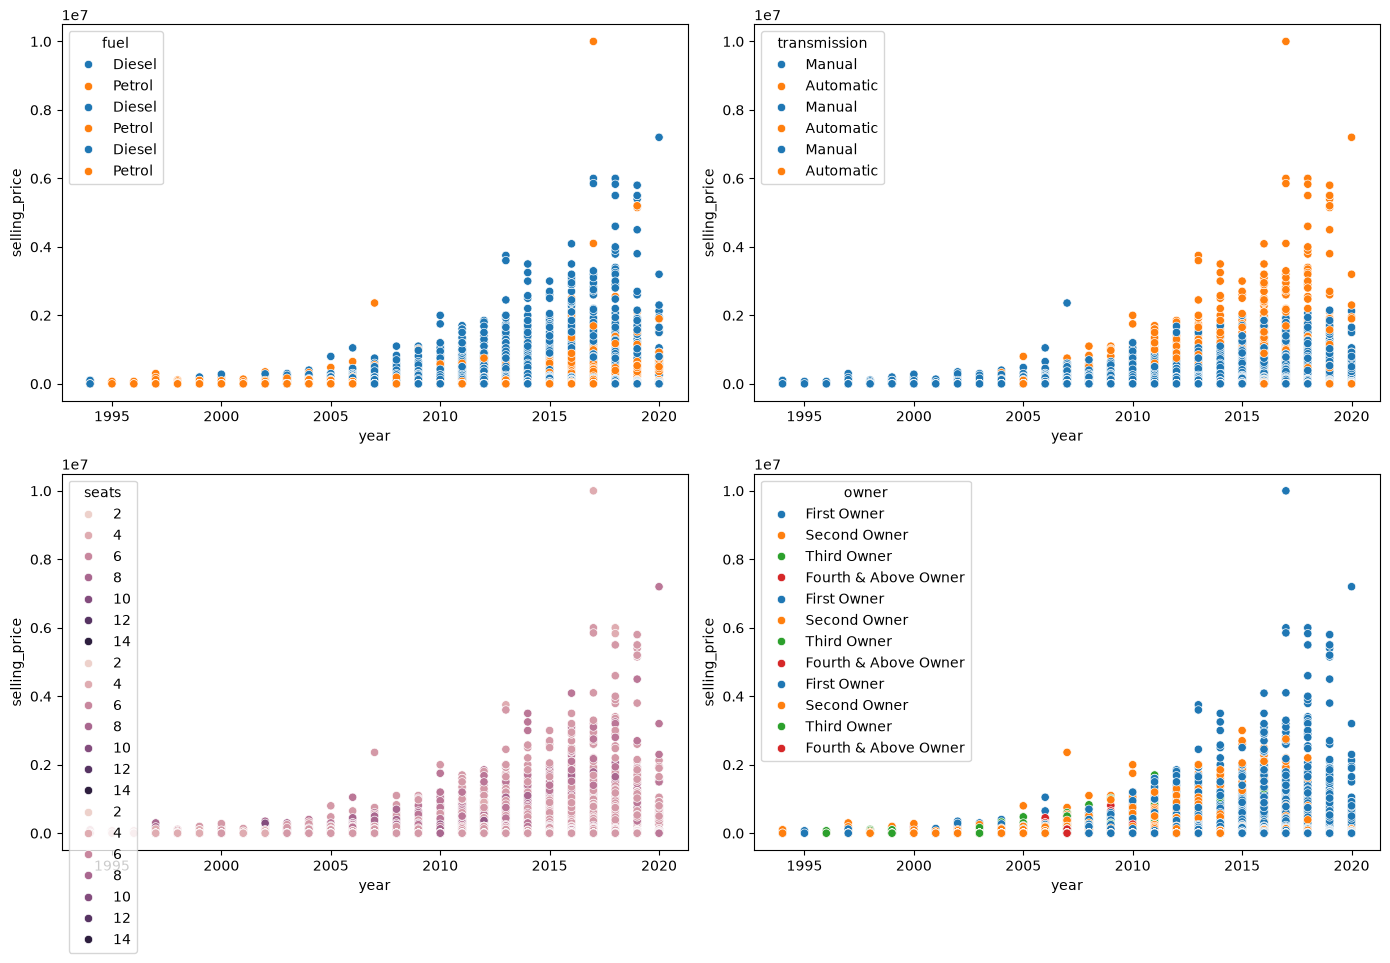

In [18]:
# ARE THESE EDA graphs ENOUGH ?

fig, axes = plt.subplots(2,2,figsize=(14,10))
axes = axes.flatten()

hue_cols = ['fuel', 'transmission', 'seats', 'owner']

for i, hue_col in enumerate(hue_cols):
    sns.scatterplot(data=df, x='year', y='selling_price', hue = hue_col, ax=axes[i])
    
for i, hue_col in enumerate(hue_cols):
    sns.scatterplot(data=df, x='year', y='km_driven', hue = hue_col, ax=axes[i])
    
for i, hue_col in enumerate(hue_cols):
    sns.scatterplot(data=df, x='year', y='mileage', hue = hue_col, ax=axes[i])


plt.tight_layout()
plt.show()

## BINNING

#### Binning Selling Price

In [19]:
# df['selling_price'].info()

<class 'pandas.core.series.Series'>
Index: 6626 entries, 0 to 8125
Series name: selling_price
Non-Null Count  Dtype
--------------  -----
6626 non-null   int64
dtypes: int64(1)
memory usage: 103.5 KB


In [20]:
# df['selling_price'].nunique()

661

In [21]:
# df['selling_price'].describe()

count    6.626000e+03
mean     5.267331e+05
std      5.116099e+05
min      2.999900e+04
25%      2.500000e+05
50%      4.220000e+05
75%      6.500000e+05
max      1.000000e+07
Name: selling_price, dtype: float64

In [23]:
# # using pd.cut()

# ## ???
# ## Difference? :
# print(df['selling_price'].min())
# print(df['selling_price'].min)

# selling_price_bins = [
#     df['selling_price'].min() - 1,
#     df['selling_price'].quantile(0.25),
#     df['selling_price'].mean(), #IS THERE A TIME WHEN WE USE MEDIAN?
#     df['selling_price'].quantile(0.25)
# ]

# bin_labels = [0,1,2,3]

# pd.cut(df['selling_price'], bins = selling_price_bins, labels = bin_labels)

## **Encoding**

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6626 entries, 0 to 8125
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           6626 non-null   int64  
 1   selling_price  6626 non-null   int64  
 2   km_driven      6626 non-null   int64  
 3   fuel           6626 non-null   object 
 4   seller_type    6626 non-null   object 
 5   transmission   6626 non-null   object 
 6   owner          6626 non-null   object 
 7   mileage        6626 non-null   float64
 8   engine         6626 non-null   float64
 9   max_power      6626 non-null   float64
 10  seats          6626 non-null   float64
 11  brand          6626 non-null   object 
dtypes: float64(4), int64(3), object(5)
memory usage: 673.0+ KB


#### **Encoding Column: Owner**

In [18]:
df["owner"].unique() 

array(['First Owner', 'Second Owner', 'Third Owner',
       'Fourth & Above Owner'], dtype=object)

In [19]:
owner_mapping = {'First Owner': 1, 'Second Owner': 2, 'Third Owner': 3,
       'Fourth & Above Owner': 4}

df['owner'] = df['owner'].map(owner_mapping)
df["owner"].unique() 

array([1, 2, 3, 4])

#### **Encoding Column: Transmission**

In [20]:
df['transmission'].unique()

array(['Manual', 'Automatic'], dtype=object)

In [21]:
transmission_mapping = { 'Manual': 1, 'Automatic': 0 }
df["transmission"] = df['transmission'].map(transmission_mapping)
df["transmission"].unique()

array([1, 0])

#### **Encoding Column: Fuel**

In [22]:
fuel_mapping = { 'Petrol': 0, 'Diesel': 1 }
df["fuel"] = df['fuel'].map(fuel_mapping)
df['fuel'].unique()

array([1, 0])

In [23]:
df['fuel'].unique()

array([1, 0])

### **Label Encoding**

In [24]:
from sklearn.preprocessing import LabelEncoder

#### **Encoding Column: Seller**

In [25]:
seller_type_encoder = LabelEncoder()
df['seller_type'] = seller_type_encoder.fit_transform(df['seller_type'])

In [26]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,brand
0,2014,450000,145500,1,1,1,1,23.40,1248.0,74.00,5.0,Maruti
1,2014,370000,120000,1,1,1,2,21.14,1498.0,103.52,5.0,Skoda
2,2006,158000,140000,0,1,1,3,17.70,1497.0,78.00,5.0,Honda
3,2010,225000,127000,1,1,1,1,23.00,1396.0,90.00,5.0,Hyundai
4,2007,130000,120000,0,1,1,1,16.10,1298.0,88.20,5.0,Maruti


## Exploratory Data Analysis (EDA) [PREVIOUS VERSIONS]

In [19]:

# num_cols = ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

# fig, axes = plt.subplots(2, 3, figsize=(18, 8))
# axes = axes.ravel()

# for i, col in enumerate(num_cols):
#     sns.histplot(df[col], kde=True, ax=axes[i])
#     axes[i].set_title(f"Distribution of {col}")
    
# plt.tight_layout()
# plt.show()


In [20]:
# df.info()

In [21]:
# df.head()

### **One Hot Encoding**

In [189]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder

In [190]:
df =df.rename(columns={'name':'brand'})
df['brand']=df['brand'].str.split().str[0]

In [191]:
oneEncoder = OneHotEncoder(sparse_output=False, dtype=int)

for column in ['brand']:
    encoded = oneEncoder.fit_transform(df[[column]])
    df[oneEncoder.get_feature_names_out([column])] = encoded
    df.drop(column, axis = 1, inplace=True)

In [192]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,...,brand_Mercedes-Benz,brand_Mitsubishi,brand_Nissan,brand_Opel,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,2014,450000,145500,1,1,1,1,23.40,1248.0,74.00,...,0,0,0,0,0,0,0,0,0,0
1,2014,370000,120000,1,1,1,2,21.14,1498.0,103.52,...,0,0,0,0,0,1,0,0,0,0
2,2006,158000,140000,0,1,1,3,17.70,1497.0,78.00,...,0,0,0,0,0,0,0,0,0,0
3,2010,225000,127000,1,1,1,1,23.00,1396.0,90.00,...,0,0,0,0,0,0,0,0,0,0
4,2007,130000,120000,0,1,1,1,16.10,1298.0,88.20,...,0,0,0,0,0,0,0,0,0,0


#### Binning Selling Price

In [193]:
selling_price_bins = [df['selling_price'].min() - 1, 
df['selling_price'].quantile(0.25), 
df['selling_price'].quantile(0.50), 
df['selling_price'].quantile(0.75),
df['selling_price'].max()]


bin_labels = [0,1,2,3]

df['selling_price'] = pd.cut(df['selling_price'], bins=selling_price_bins, labels = bin_labels, include_lowest = True)

df['selling_price'] = df['selling_price'].astype(int)

df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,...,brand_Mercedes-Benz,brand_Mitsubishi,brand_Nissan,brand_Opel,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,2014,2,145500,1,1,1,1,23.40,1248.0,74.00,...,0,0,0,0,0,0,0,0,0,0
1,2014,1,120000,1,1,1,2,21.14,1498.0,103.52,...,0,0,0,0,0,1,0,0,0,0
2,2006,0,140000,0,1,1,3,17.70,1497.0,78.00,...,0,0,0,0,0,0,0,0,0,0
3,2010,0,127000,1,1,1,1,23.00,1396.0,90.00,...,0,0,0,0,0,0,0,0,0,0
4,2007,0,120000,0,1,1,1,16.10,1298.0,88.20,...,0,0,0,0,0,0,0,0,0,0


In [194]:
df['selling_price'] = df['selling_price'].astype(int)
df['selling_price'].unique()

array([2, 1, 0, 3])

#### *Train and Test Split*

In [195]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [196]:
df['selling_price'].describe()
df['selling_price'].dtype

dtype('int64')

In [197]:

X = df.drop(columns='selling_price')
y = df['selling_price']

print("BEFORE SPLIT:")
print(type(X))
print(type(y))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nAFTER SPLIT:")
print(type(X_train))
print(type(X_test))
print(type(y_train))
print(type(y_test))

BEFORE SPLIT:
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>

AFTER SPLIT:
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


### Scaling

In [198]:
X_train.head()

,year,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,...,brand_Mercedes-Benz,brand_Mitsubishi,brand_Nissan,brand_Opel,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
3890,1995,70000,0,1,1,1,16.10,796.0,37.0,4.0,...,0,0,0,0,0,0,0,0,0,0
6291,2017,76000,1,0,1,1,25.47,1248.0,88.5,7.0,...,0,0,0,0,0,0,0,0,0,0
4492,2015,190000,1,1,1,1,12.99,2494.0,100.6,7.0,...,0,0,0,0,0,0,0,1,0,0
6794,2012,120000,1,1,1,1,23.03,1396.0,69.0,5.0,...,0,0,0,0,0,0,1,0,0,0
2786,2015,120000,1,1,1,2,19.10,1405.0,70.0,5.0,...,0,0,0,0,0,0,1,0,0,0


Scaling X_train and X_test

In [199]:
scaler = StandardScaler()

# Deciding on which cols to scale
scal_col = ['year', 'km_driven', 'mileage', 'engine', 'max_power']

print(X_train[scal_col].head())
for col in scal_col:
    print(X_train[col].describe())
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# print(X_train)
# print(X_test)
# print(X_train_scaled)
# print(X_test_scaled)

      year  km_driven  mileage  engine  max_power
3890  1995      70000    16.10   796.0       37.0
6291  2017      76000    25.47  1248.0       88.5
4492  2015     190000    12.99  2494.0      100.6
6794  2012     120000    23.03  1396.0       69.0
2786  2015     120000    19.10  1405.0       70.0
count    5300.000000
mean     2013.594528
std         3.910193
min      1994.000000
25%      2011.000000
50%      2014.000000
75%      2017.000000
max      2020.000000
Name: year, dtype: float64
count    5.300000e+03
mean     7.338788e+04
std      6.033798e+04
min      1.000000e+03
25%      3.700000e+04
50%      6.900000e+04
75%      1.000000e+05
max      2.360457e+06
Name: km_driven, dtype: float64
count    5300.000000
mean       19.449770
std         3.983584
min         0.000000
25%        16.800000
50%        19.400000
75%        22.500000
max        42.000000
Name: mileage, dtype: float64
count    5300.000000
mean     1437.537547
std       495.202420
min       624.000000
25%      1197.0

In [200]:
X_train[['year', 'km_driven']].head()

,year,km_driven
3890,1995,70000
6291,2017,76000
4492,2015,190000
6794,2012,120000
2786,2015,120000


In [201]:
X_train[['year', 'km_driven']].describe()

,year,km_driven
count,5300.000000,5.300000e+03
mean,2013.594528,7.338788e+04
std,3.910193,6.033798e+04
min,1994.000000,1.000000e+03
25%,2011.000000,3.700000e+04
50%,2014.000000,6.900000e+04
75%,2017.000000,1.000000e+05
max,2020.000000,2.360457e+06


In [202]:

print(X_train.head())
print(X_test.head())

X_train[scal_col] = scaler.fit_transform(X_train[scal_col])
X_test[scal_col] = scaler.fit_transform(X_test[scal_col])

print(X_train.head())
print(X_test.head())


      year  km_driven  fuel  seller_type  transmission  owner  mileage  \
3890  1995      70000     0            1             1      1    16.10   
6291  2017      76000     1            0             1      1    25.47   
4492  2015     190000     1            1             1      1    12.99   
6794  2012     120000     1            1             1      1    23.03   
2786  2015     120000     1            1             1      2    19.10   

      engine  max_power  seats  ...  brand_Mercedes-Benz  brand_Mitsubishi  \
3890   796.0       37.0    4.0  ...                    0                 0   
6291  1248.0       88.5    7.0  ...                    0                 0   
4492  2494.0      100.6    7.0  ...                    0                 0   
6794  1396.0       69.0    5.0  ...                    0                 0   
2786  1405.0       70.0    5.0  ...                    0                 0   

      brand_Nissan  brand_Opel  brand_Renault  brand_Skoda  brand_Tata  \
3890        

In [203]:
print(X_test)

          year  km_driven  fuel  seller_type  transmission  owner   mileage  \
5494 -0.693918   0.123808     0            1             1      2  0.416552   
5373  0.344024  -0.067244     1            1             1      1 -0.966428   
4693  0.603509   0.314860     1            1             0      2 -0.216707   
5722 -1.731860   0.696964     1            1             1      1 -2.155305   
5425 -0.953403   0.467701     1            1             1      1 -0.384121   
...        ...        ...   ...          ...           ...    ...       ...   
5701 -0.693918  -0.640399     0            1             1      2  0.237007   
1462 -0.693918  -0.258296     1            1             1      2  0.416552   
7533  0.862995  -1.118029     0            1             1      1  1.290013   
5415 -2.250831   2.187168     1            1             1      1 -1.718575   
7339  0.603509  -1.213555     0            0             0      1  0.901808   

        engine  max_power  seats  ...  brand_Merced

#### Outliers

year: 45 outliers (0.85%)
km_driven: 116 outliers (2.19%)
mileage: 8 outliers (0.15%)
engine: 979 outliers (18.47%)
max_power: 243 outliers (4.58%)


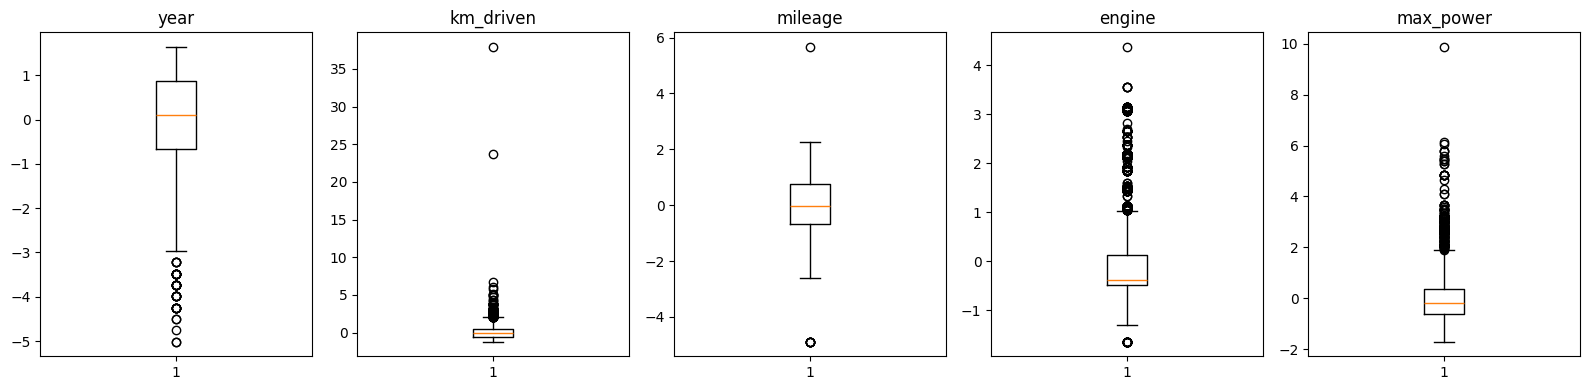

In [204]:
fig, axes = plt.subplots(1, len(scal_col), figsize=(16, 4))

for i, col in enumerate(scal_col):
    bp = axes[i].boxplot(X_train[col], vert=True)
    axes[i].set_title(col)
    
    # 'fliers' = the points matplotlib drew as outliers
    n_outliers = len(bp['fliers'][0].get_ydata())
    percent = round(n_outliers / len(X_train[col]) * 100, 2)
    print(f"{col}: {n_outliers} outliers ({percent}%)")

plt.tight_layout()
plt.show()

In [205]:
# # OUTLIER DETECTION FOR REGRESSION
# fig, axes = plt.subplots(1, 5, figsize=(22, 4))

# for i, col in enumerate(scal_col):
#     sns.regplot(
#         x=X_train[col], 
#         y=y_train, 
#         ax=axes[i], 
#         scatter_kws={'alpha': 0.2, 'color': 'steelblue', 's': 15}, 
#         line_kws={'color': 'darkred', 'linewidth': 2}
#     )
#     axes[i].axvline(0, color='gray', linestyle=':', alpha=0.7)
#     axes[i].set_title(f"{col} vs log(price)", fontsize=12)
#     axes[i].set_xlabel(f"Scaled {col} ($z$-score)")
#     axes[i].set_ylabel("log(selling_price)" if i == 0 else "")

# plt.suptitle("Scaled Features vs. log(selling_price) with Trendline", fontsize=14, y=1.05)
# plt.tight_layout()
# plt.show()


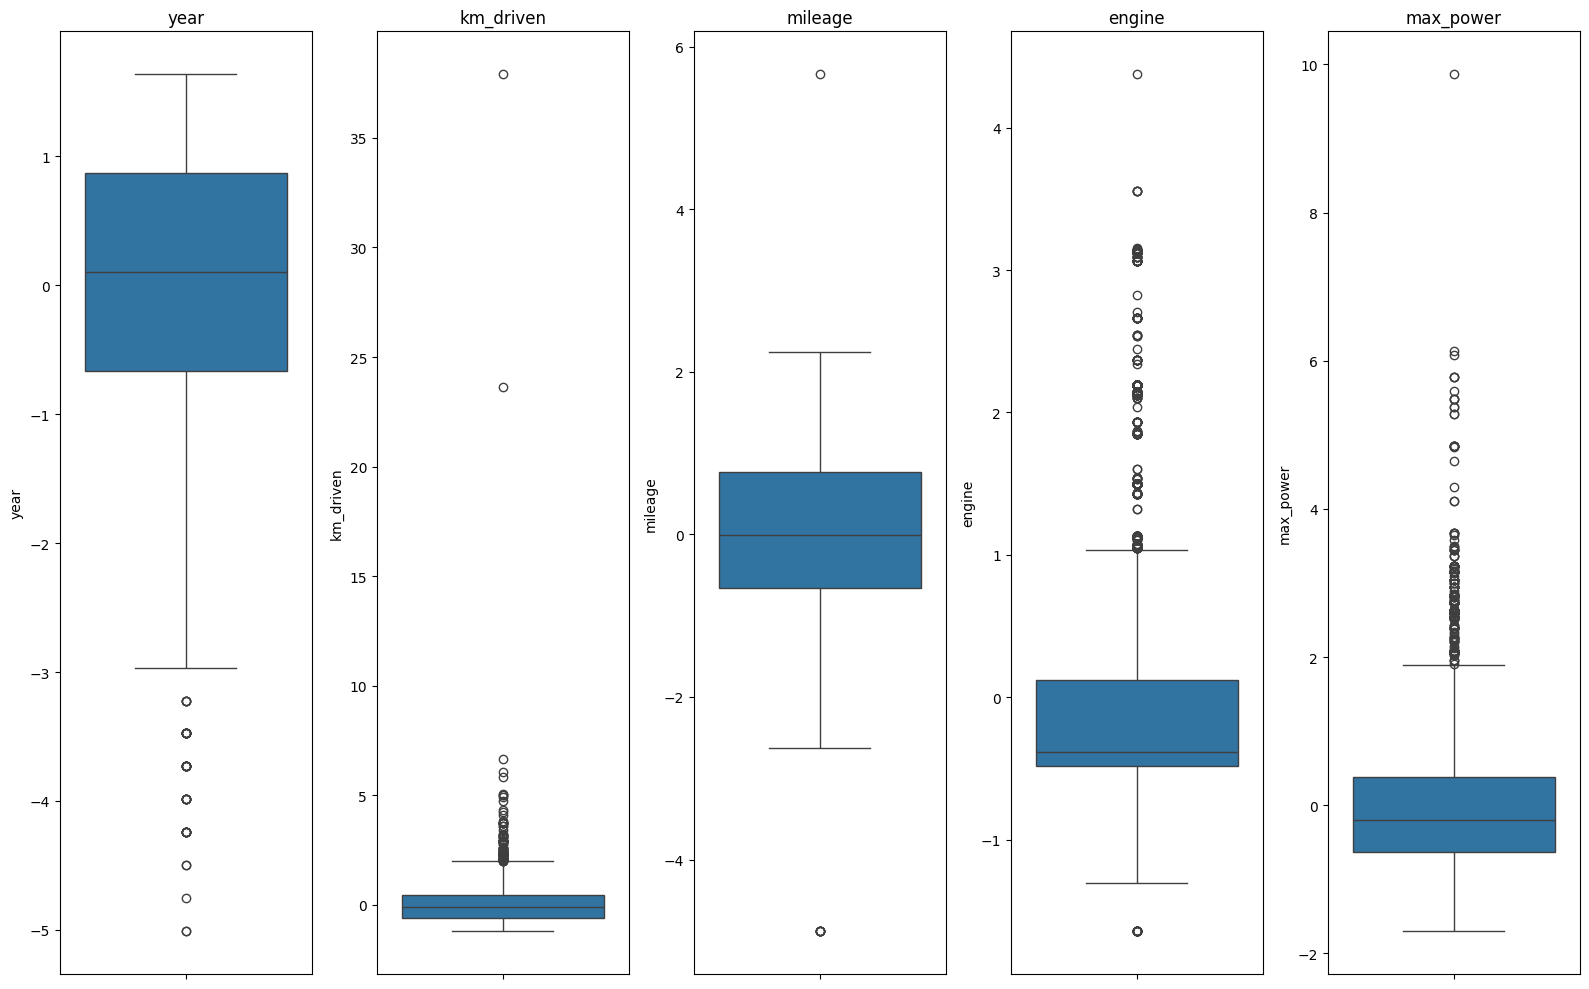

In [206]:
fig, axes = plt.subplots(1, len(scal_col), figsize=(16,10))

for i, col in enumerate(scal_col):
    sns.boxplot(data=X_train, y=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


In [207]:
# Count outliers per column using the standard IQR method

def outlier_count(col, data=X_train):
    q75, q25 = np.percentile(data[col], [75, 25])
    iqr = q75 - q25
    min_val = q25 - (iqr * 1.5)
    max_val = q75 + (iqr * 1.5)
    count = len(np.where((data[col] > max_val) | (data[col] < min_val))[0])
    percent = round(count / len(data[col]) * 100, 2)
    if count > 0:
        print("\n" + 15*'-' + col + 15*'-' + "\n")
        print('Number of outliers: {}'.format(count))
        print('Percent of data that is outlier: {}%'.format(percent))

for col in scal_col:
    outlier_count(col)



---------------year---------------

Number of outliers: 45
Percent of data that is outlier: 0.85%

---------------km_driven---------------

Number of outliers: 116
Percent of data that is outlier: 2.19%

---------------mileage---------------

Number of outliers: 8
Percent of data that is outlier: 0.15%

---------------engine---------------

Number of outliers: 979
Percent of data that is outlier: 18.47%

---------------max_power---------------

Number of outliers: 243
Percent of data that is outlier: 4.58%


## Modeling

### Defining the model

In [208]:
import time
from sklearn.metrics import classification_report

In [252]:
class LogisticRegression:

    def __init__(self, k, n, method, alpha = 0.001, max_iter=5000):
        self.k = k
        self.n = n
        self.alpha = alpha
        self.max_iter = max_iter
        self.method = method
    
    def fit(self, X, Y):
        X = np.asarray(X)
        Y = np.asarray(Y)
        self.W = np.random.rand(self.n, self.k)
        self.losses = []
        
        if self.method == "batch":
            start_time = time.time()
            for i in range(self.max_iter):
                loss, grad =  self.gradient(X, Y)
                self.losses.append(loss)
                self.W = self.W - self.alpha * grad
                if i % 500 == 0:
                    print(f"Loss at iteration {i}", loss)
            print(f"time taken: {time.time() - start_time}")
            
        elif self.method == "minibatch":
            start_time = time.time()
            batch_size = int(0.3 * X.shape[0])
            for i in range(self.max_iter):
                ix = np.random.randint(0, X.shape[0]) #<----with replacement
                batch_X = X[ix:ix+batch_size]
                batch_Y = Y[ix:ix+batch_size]
                loss, grad = self.gradient(batch_X, batch_Y)
                self.losses.append(loss)
                self.W = self.W - self.alpha * grad
                if i % 500 == 0:
                    print(f"Loss at iteration {i}", loss)
            print(f"time taken: {time.time() - start_time}")
            
        elif self.method == "sto":
            start_time = time.time()
            list_of_used_ix = []
            for i in range(self.max_iter):
                idx = np.random.randint(X.shape[0])
                while i in list_of_used_ix:
                    idx = np.random.randint(X.shape[0])
                X_train = X[idx, :].reshape(1, -1)
                Y_train = Y[idx]
                loss, grad = self.gradient(X_train, Y_train)
                self.losses.append(loss)
                self.W = self.W - self.alpha * grad
                
                list_of_used_ix.append(i)
                if len(list_of_used_ix) == X.shape[0]:
                    list_of_used_ix = []
                if i % 500 == 0:
                    print(f"Loss at iteration {i}", loss)
            print(f"time taken: {time.time() - start_time}")
            
        else:
            raise ValueError('Method must be one of the followings: "batch", "minibatch" or "sto".')
        
        
    def gradient(self, X, Y):
        m = X.shape[0]
        h = self.h_theta(X, self.W)
        loss = - np.sum(Y*np.log(h)) / m
        error = h - Y
        grad = self.softmax_grad(X, error)
        return loss, grad

    def softmax(self, theta_t_x):
        return np.exp(theta_t_x) / np.sum(np.exp(theta_t_x), axis=1, keepdims=True)

    def softmax_grad(self, X, error):
        return  X.T @ error

    def h_theta(self, X, W):
        '''
        Input:
            X shape: (m, n)
            w shape: (n, k)
        Returns:
            yhat shape: (m, k)
        '''
        return self.softmax(X @ W)
    
    def predict(self, X_test):
        X_test = np.asarray(X_test)    
        return np.argmax(self.h_theta(X_test, self.W), axis=1)

    # FUNCTION TO CALCULATE ACCURACY SCORE
    def accuracy(self, yhat, y_test):
        y_test = np.asarray(y_test)
        yhat = np.asarray(yhat)
        correct_pred = 0
        if yhat.shape[0] == y_test.shape[0]:
            for index in range(len(y_test)):
                if yhat[index] == y_test[index]:
                    correct_pred = correct_pred + 1
        all_predictions = y_test.shape[0]
        accuracy_score = correct_pred / all_predictions
        return accuracy_score  

    def confusion_matrix(self, yhat, y_test, c):
        TP = TN = FP = FN =  0
        y_pred = np.asarray(yhat)
        y_true = np.asarray(y_test)
        
        for i in range(len(y_test)):
            pred_c = (y_pred[i] == c)
            true_c = (y_true[i] == c)
            
            if pred_c and true_c:
                TP = TP + 1
            elif pred_c and not true_c:
                FP = FP + 1
            elif (not pred_c) and not true_c:
                TN = TN + 1
            else:
                FN = FN + 1
        return (TP,FP,TN,FN)
    
    def precision(self, TP, FP):
        return TP / (TP + FP)

    def recall(self, TP, FN):
        return TP / (TP + FN)
        
    def f1(self, precision, recall):
        return (2 * precision * recall) / (precision + recall)
        
    def macro_precision(precision_list):
        sum_prec = 0
        for precision in precision_list:
            sum_prec = sum_prec + precision
        m_precision = sum_prec / len(precision_list)
        return m_precision
        
    def macro_recall(recall_list):
        sum_rec = 0
        for recall in recall_list:
            sum_rec = sum_rec + recall
        m_recall = sum_rec / len(recall_list)
        return m_recall

    def macro_f1(f1_list):
        sum_f1 = 0
        for f1 in f1_list:
            sum_f1 = sum_f1 + f1
        m_f1 = sum_f1 / len(f1_list)
        return m_f1

    def plot(self):
        plt.plot(np.arange(len(self.losses)) , self.losses, label = "Train Losses")
        plt.title("Losses")
        plt.xlabel("epoch")
        plt.ylabel("losses")
        plt.legend()

In [234]:
# y train is now (m,k)
m = X_train.shape[0]
k = y.nunique()
Y_train_encoded = np.zeros((m, k))
for each_class in range(k):
    cond = y_train==each_class
    Y_train_encoded[np.where(cond), each_class] = 1
print(y_train)
print(Y_train_encoded)

3890    0
6291    3
4492    3
6794    0
2786    0
       ..
4553    0
6321    2
6362    2
6531    2
948     0
Name: selling_price, Length: 5300, dtype: int64
[[1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 ...
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]]


In [235]:
print(Y_train_encoded.dtype)

float64


Loss at iteration 0 2.183458002172855
Loss at iteration 500 4.073424729747407
Loss at iteration 1000 3.7827866976076767
Loss at iteration 1500 1.741003981144258
Loss at iteration 2000 5.989275702089752
Loss at iteration 2500 5.0994077784670635
Loss at iteration 3000 3.0116744667675515
Loss at iteration 3500 5.376482091883819
Loss at iteration 4000 3.579454393780996
Loss at iteration 4500 4.975784221145437
time taken: 1.6343715190887451
=========Classification report=======
Report:                precision    recall  f1-score   support

           0       0.77      0.88      0.82       330
           1       0.66      0.53      0.59       336
           2       0.63      0.67      0.65       347
           3       0.82      0.82      0.82       313

    accuracy                           0.72      1326
   macro avg       0.72      0.72      0.72      1326
weighted avg       0.72      0.72      0.72      1326



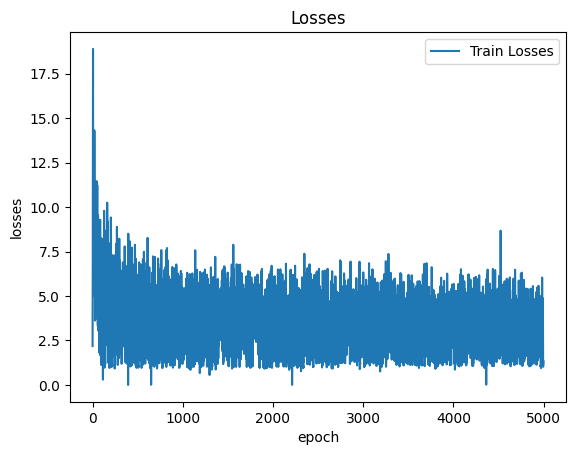

In [236]:
model = LogisticRegression(k, X_train.shape[1], "minibatch")
model.fit(X_train, Y_train_encoded)
yhat = model.predict(X_test)
model.plot()
print("=========Classification report=======")
print("Report: ", classification_report(y_test, yhat))

In [237]:
acc_score = model.accuracy(yhat, y_test)
print("Accuracy Score:", acc_score)

Accuracy Score: 0.7217194570135747


In [238]:
print(yhat)

[0 3 3 ... 1 0 2]


In [239]:
# print(y_test)

In [240]:
# yhat_arr = np.asarray(yhat)
# print(yhat_arr)
# print(yhat)
# print(y_test)
# np.unique(yhat_arr)

In [241]:
y_test

5494    0
5373    3
4693    2
5722    1
5425    1
       ..
5701    0
1462    0
7533    1
5415    0
7339    2
Name: selling_price, Length: 1326, dtype: int64

In [242]:
# def confusion_matrix(yhat, y_test, ):

# for clas in y_test.unique()

In [253]:
# Used for later tasks
precisions = []
recalls = []
f1_list = []

for i in y_test.unique():
    print("For class: ", i)
    TP,FP,TN,FN = model.confusion_matrix(yhat, y_test, i)

    print("TP: ", TP,"FP: ", FP, "TN: ", TN, "FN: ", FN) 
    print("Sum of all to verify: ", (TP + FP + TN + FN) )
    
    precision_c = model.precision(TP, FP)
    precisions.append(precision_c)
    print("Precision: ", precision_c )
    
    recall_c = model.precision(TP, FP)
    recalls.append(recall_c)
    print("Recall: ", model.recall(TP, FN) )
    
    f1_c = model.f1(precision_c, recall_c)
    f1_list.append(f1_c)
    print("f1: ", f1_c )

    print("\n")

For class:  0
TP:  291 FP:  87 TN:  909 FN:  39
Sum of all to verify:  1326
Precision:  0.7698412698412699
Recall:  0.8818181818181818
f1:  0.7698412698412699


For class:  3
TP:  258 FP:  57 TN:  956 FN:  55
Sum of all to verify:  1326
Precision:  0.819047619047619
Recall:  0.8242811501597445
f1:  0.819047619047619


For class:  2
TP:  231 FP:  133 TN:  846 FN:  116
Sum of all to verify:  1326
Precision:  0.6346153846153846
Recall:  0.6657060518731989
f1:  0.6346153846153846


For class:  1
TP:  177 FP:  92 TN:  898 FN:  159
Sum of all to verify:  1326
Precision:  0.6579925650557621
Recall:  0.5267857142857143
f1:  0.6579925650557621




In [244]:
something = y_test.unique()
something

for s in something:
    print(s)

0
3
2
1


In [245]:
# y_test.unique()[0]

In [246]:
# c = y_test.unique()[0]
# y_pred = np.asarray(yhat)
# y_true = np.asarray(y_test)
# print(yhat)

In [247]:
# y_pred = np.asarray(yhat)
# y_true = np.asarray(y_test)
# # model_cond = (y_pred == y_true)
# # print(model_cond)

# TP = TN = FP = 0

# for i in range(len(y_test)):
#     pred_c = (y_pred[i] == c)
#     true_c = (y_true[i] == c)
#     print(pred_c)
#     print(true_c)
#     # if model_cond:
#     #     print("model_cond, model_cond")
#     if pred_c and true_c:
#         print("True Positive")
#         TP = TP + 1
#     elif pred_c and not true_c:
#         print("False Positive")
#         FP = FP + 1
#     elif (not pred_c) and not true_c:
#         print("False Positive")
#         TN = TN + 1
#     else:
#         FN = FN + 1

